In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, RocCurveDisplay, roc_curve

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance


In [3]:
data_path = "../data/training.csv"
df = pd.read_csv(data_path)
df.shape

(250000, 33)

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
EventId,250000.0,224999.500000,72168.927986,100000.000000,162499.750000,224999.500000,287499.250000,349999.00000
DER_mass_MMC,250000.0,-49.023079,406.345647,-999.000000,78.100750,105.012000,130.606250,1192.02600
DER_mass_transverse_met_lep,250000.0,49.239819,35.344886,0.000000,19.241000,46.524000,73.598000,690.07500
DER_mass_vis,250000.0,81.181982,40.828691,6.329000,59.388750,73.752000,92.259000,1349.35100
DER_pt_h,250000.0,57.895962,63.655682,0.000000,14.068750,38.467500,79.169000,2834.99900
DER_deltaeta_jet_jet,250000.0,-708.420675,454.480565,-999.000000,-999.000000,-999.000000,0.490000,8.50300
DER_mass_jet_jet,250000.0,-601.237051,657.972302,-999.000000,-999.000000,-999.000000,83.446000,4974.97900
DER_prodeta_jet_jet,250000.0,-709.356603,453.019877,-999.000000,-999.000000,-999.000000,-4.593000,16.69000
DER_deltar_tau_lep,250000.0,2.373100,0.782911,0.208000,1.810000,2.491500,2.961000,5.68400
DER_pt_tot,250000.0,18.917332,22.273494,0.000000,2.841000,12.315500,27.591000,2834.99900


In [5]:
df["Label"].value_counts(normalize=True)

Label
b    0.657332
s    0.342668
Name: proportion, dtype: float64

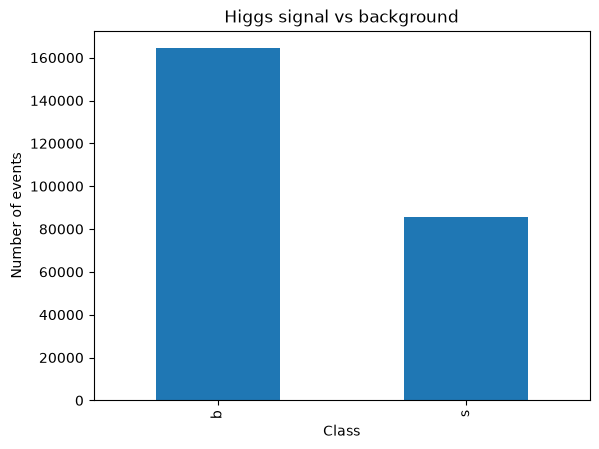

In [6]:
df["Label"].value_counts().plot(kind="bar")

plt.xlabel("Class")
plt.ylabel("Number of events")
plt.title("Higgs signal vs background")
plt.show()

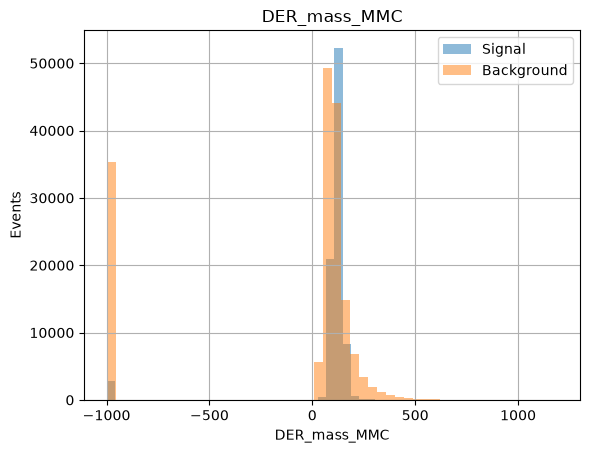

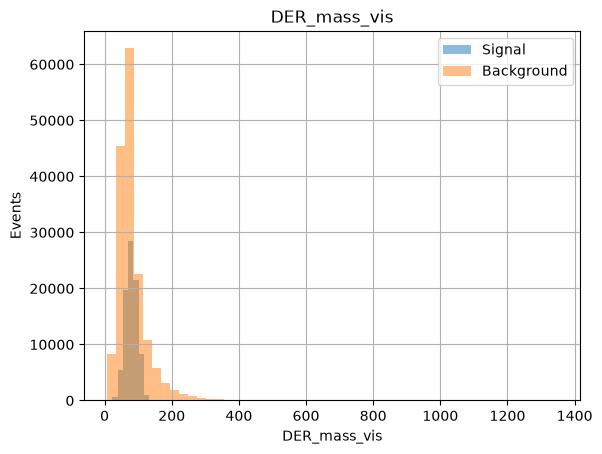

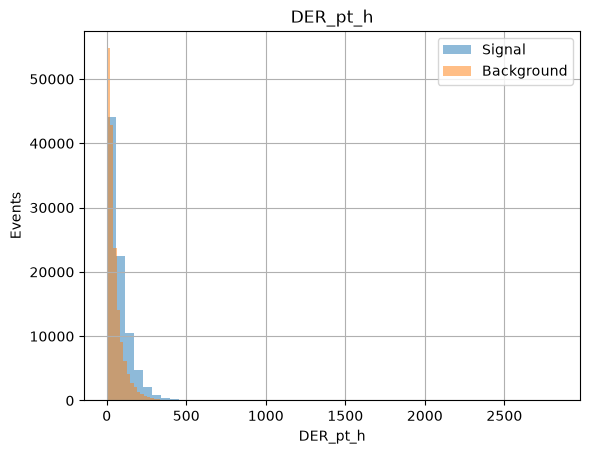

In [7]:
variables = [
    "DER_mass_MMC",
    "DER_mass_vis",
    "DER_pt_h",
]

for variable in variables:
    plt.figure()

    df[df["Label"] == "s"][variable].hist(
        bins=50,
        alpha=0.5,
        label="Signal"
    )

    df[df["Label"] == "b"][variable].hist(
        bins=50,
        alpha=0.5,
        label="Background"
    )

    plt.xlabel(variable)
    plt.ylabel("Events")
    plt.title(variable)
    plt.legend()

    plt.show()

In [8]:
missing_mmc = (df["DER_mass_MMC"] == -999)

print(f"Unavailable MMC values: {missing_mmc.sum():,}")
print(f"Fraction: {missing_mmc.mean():.1%}")

Unavailable MMC values: 38,114
Fraction: 15.2%


In [9]:
pd.crosstab(
    df["Label"],
    missing_mmc,
    normalize="index"
)

DER_mass_MMC,False,True
Label,,
b,0.785320,0.214680
s,0.966907,0.033093


In [10]:
feature_columns = [
    column
    for column in df.columns
    if column not in ["EventId", "Weight", "Label"]
]

X = df[feature_columns]
y = (df["Label"] == "s").astype(int)

print("Number of features:", X.shape[1])
print("Number of events:", X.shape[0])
print("Signal fraction:", y.mean())

Number of features: 30
Number of events: 250000
Signal fraction: 0.342668


In [11]:
(X == -999).sum().sort_values(ascending=False)

DER_deltaeta_jet_jet           177457
DER_mass_jet_jet               177457
DER_lep_eta_centrality         177457
DER_prodeta_jet_jet            177457
PRI_jet_subleading_pt          177457
PRI_jet_subleading_phi         177457
PRI_jet_subleading_eta         177457
PRI_jet_leading_pt              99913
PRI_jet_leading_eta             99913
PRI_jet_leading_phi             99913
DER_mass_MMC                    38114
DER_pt_h                            0
DER_mass_vis                        0
DER_mass_transverse_met_lep         0
PRI_tau_pt                          0
DER_met_phi_centrality              0
DER_pt_ratio_lep_tau                0
DER_sum_pt                          0
DER_deltar_tau_lep                  0
DER_pt_tot                          0
PRI_tau_eta                         0
PRI_tau_phi                         0
PRI_met_sumet                       0
PRI_met_phi                         0
PRI_met                             0
PRI_lep_phi                         0
PRI_lep_eta 

In [12]:
X = X.replace(-999, np.nan)
X.isna().sum().sort_values(ascending=False)

DER_deltaeta_jet_jet           177457
DER_mass_jet_jet               177457
DER_lep_eta_centrality         177457
DER_prodeta_jet_jet            177457
PRI_jet_subleading_pt          177457
PRI_jet_subleading_phi         177457
PRI_jet_subleading_eta         177457
PRI_jet_leading_pt              99913
PRI_jet_leading_eta             99913
PRI_jet_leading_phi             99913
DER_mass_MMC                    38114
DER_pt_h                            0
DER_mass_vis                        0
DER_mass_transverse_met_lep         0
PRI_tau_pt                          0
DER_met_phi_centrality              0
DER_pt_ratio_lep_tau                0
DER_sum_pt                          0
DER_deltar_tau_lep                  0
DER_pt_tot                          0
PRI_tau_eta                         0
PRI_tau_phi                         0
PRI_met_sumet                       0
PRI_met_phi                         0
PRI_met                             0
PRI_lep_phi                         0
PRI_lep_eta 

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print(y_train.mean())
print(y_test.mean())

0.34267
0.34266


In [14]:
logistic_model = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=1000)),
])
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['DER_mass_MMC','DER_mass_transverse_met_lep','DER_mass_vis',..., 'PRI_jet_subleading_eta','PRI_jet_subleading_phi','PRI_jet_all_pt']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to

In [15]:
logistic_model.predict_proba(X_test)

array([[0.96398233, 0.03601767],
       [0.98050812, 0.01949188],
       [0.76651916, 0.23348084],
       ...,
       [0.9186948 , 0.0813052 ],
       [0.89316032, 0.10683968],
       [0.75400167, 0.24599833]], shape=(50000, 2))

In [19]:
y_score = logistic_model.predict_proba(X_test)[:, 1]
y_score

array([0.03601767, 0.01949188, 0.23348084, ..., 0.0813052 , 0.10683968,
       0.24599833], shape=(50000,))

In [21]:
logistic_auc = roc_auc_score(y_test, y_score) #for binary classification only
print(f"ROC-AUC = {logistic_auc:.4f}")

ROC-AUC = 0.8123


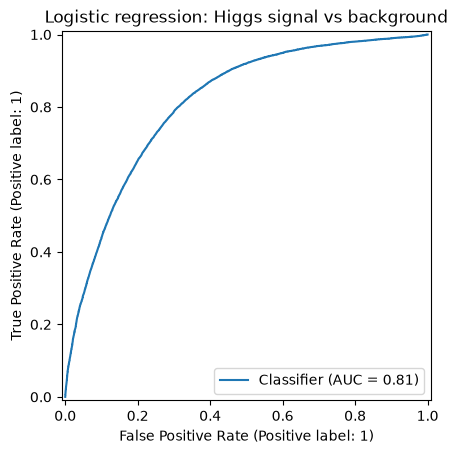

In [33]:
RocCurveDisplay.from_predictions(
    y_test,
    y_score,
)

plt.title("Logistic regression: Higgs signal vs background")
plt.show()

In [16]:
boosted_model = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42,
)

In [17]:
boosted_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [18]:
boosted_score = boosted_model.predict_proba(X_test)[:, 1]
boosted_score

array([0.00527121, 0.01016168, 0.10279604, ..., 0.00932065, 0.03699647,
       0.03200128], shape=(50000,))

In [20]:
boosted_auc = roc_auc_score(
    y_test,
    boosted_score,
)

print(f"Boosted-tree ROC-AUC = {boosted_auc:.4f}")

Boosted-tree ROC-AUC = 0.9088


In [22]:
print(f"Logistic regression: {logistic_auc:.4f}")
print(f"Boosted trees:       {boosted_auc:.4f}")

Logistic regression: 0.8123
Boosted trees:       0.9088


In [23]:
fpr_logistic, tpr_logistic, _ = roc_curve(
    y_test,
    y_score,
)

fpr_boosted, tpr_boosted, _ = roc_curve(
    y_test,
    boosted_score,
)

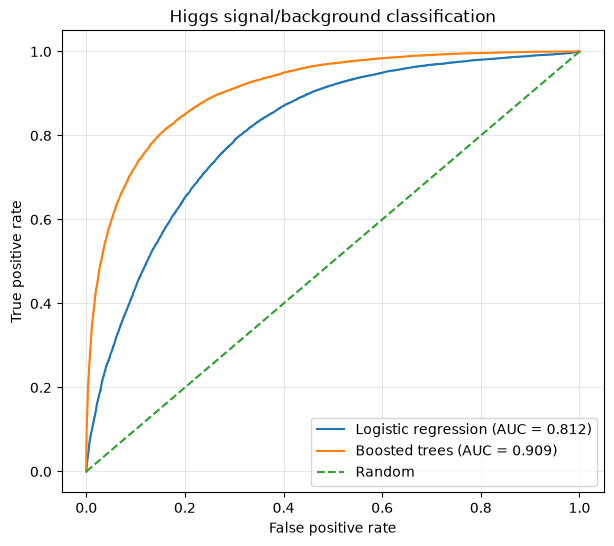

In [24]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_logistic,
    tpr_logistic,
    label=f"Logistic regression (AUC = {logistic_auc:.3f})",
)

plt.plot(
    fpr_boosted,
    tpr_boosted,
    label=f"Boosted trees (AUC = {boosted_auc:.3f})",
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random",
)

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("Higgs signal/background classification")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [25]:
result = permutation_importance(
    boosted_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=5,
    random_state=42,
    n_jobs=-1,
)

In [26]:
importance = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean,
})

In [27]:
importance = importance.sort_values(
    "importance",
    ascending=False,
)
importance.head(10)

,feature,importance
0,DER_mass_MMC,0.117286
2,DER_mass_vis,0.035653
1,DER_mass_transverse_met_lep,0.033560
13,PRI_tau_pt,0.017404
7,DER_deltar_tau_lep,0.011366
24,PRI_jet_leading_eta,0.006634
11,DER_met_phi_centrality,0.006113
17,PRI_lep_eta,0.004046
12,DER_lep_eta_centrality,0.003946
5,DER_mass_jet_jet,0.002785


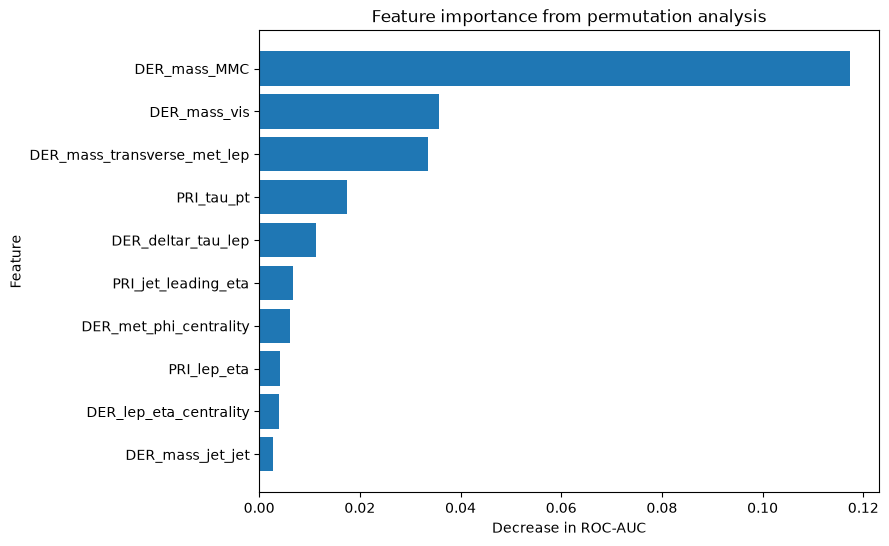

In [28]:
top_n = 10

top_features = importance.head(top_n)

plt.figure(figsize=(8, 6))

plt.barh(
    top_features["feature"][::-1],
    top_features["importance"][::-1],
)

plt.xlabel("Decrease in ROC-AUC")
plt.ylabel("Feature")
plt.title("Feature importance from permutation analysis")
plt.show()

In [29]:
#Let's now make a classifier using only the top 10 features.

top_feature_names = importance.head(10)["feature"].tolist()

X_train_top = X_train[top_feature_names]
X_test_top = X_test[top_feature_names]

In [30]:
boosted_top = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42,
)

boosted_top.fit(X_train_top, y_train)

,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [31]:
top_score = boosted_top.predict_proba(X_test_top)[:, 1]

In [32]:
top_auc = roc_auc_score(y_test, top_score)

print(f"All 30 features: {boosted_auc:.4f}")
print(f"Top 10 features: {top_auc:.4f}")

All 30 features: 0.9088
Top 10 features: 0.9037


In [33]:
#We can create validation data from X_train
X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

print("Training:", X_train_model.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (160000, 30)
Validation: (40000, 30)
Test: (50000, 30)


In [34]:
model_small = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=15,
    random_state=42,
)

model_small.fit(X_train_model, y_train_model)

,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",15
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",100
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [35]:
train_score = model_small.predict_proba(X_train_model)[:, 1]
val_score = model_small.predict_proba(X_val)[:, 1]

train_auc = roc_auc_score(y_train_model, train_score)
val_auc = roc_auc_score(y_val, val_score)

print(f"Training AUC:   {train_auc:.4f}")
print(f"Validation AUC: {val_auc:.4f}")

Training AUC:   0.9109
Validation AUC: 0.9076


In [36]:
model_complex = HistGradientBoostingClassifier(
    max_iter=500,
    learning_rate=0.1,
    max_leaf_nodes=127,
    random_state=42,
)

model_complex.fit(X_train_model, y_train_model)

,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",500
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",127
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing va

In [38]:
complex_train_score = model_complex.predict_proba(X_train_model)[:, 1]
complex_val_score = model_complex.predict_proba(X_val)[:, 1]

complex_train_auc = roc_auc_score(y_train_model, complex_train_score)
complex_val_auc = roc_auc_score(y_val, complex_val_score)

print(f"Training AUC:   {complex_train_auc:.4f}")
print(f"Validation AUC: {complex_val_auc:.4f}")

Training AUC:   0.9346
Validation AUC: 0.9110


In [39]:
iterations = [20, 50, 100, 200, 400, 600]

train_auc_values = []
val_auc_values = []

for n in iterations:
    model = HistGradientBoostingClassifier(
        max_iter=n,
        learning_rate=0.1,
        max_leaf_nodes=31,
        random_state=42,
    )

    model.fit(X_train_model, y_train_model)

    train_pred = model.predict_proba(X_train_model)[:, 1]
    val_pred = model.predict_proba(X_val)[:, 1]

    train_auc_values.append(roc_auc_score(y_train_model, train_pred))
    val_auc_values.append(roc_auc_score(y_val, val_pred))

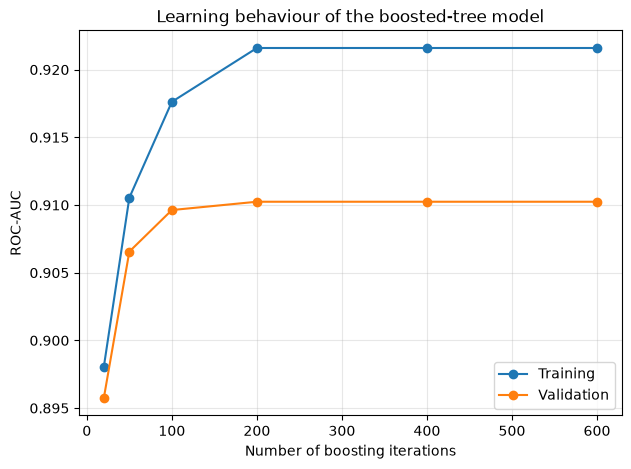

In [40]:
plt.figure(figsize=(7, 5))

plt.plot(
    iterations,
    train_auc_values,
    marker="o",
    label="Training",
)

plt.plot(
    iterations,
    val_auc_values,
    marker="o",
    label="Validation",
)

plt.xlabel("Number of boosting iterations")
plt.ylabel("ROC-AUC")
plt.title("Learning behaviour of the boosted-tree model")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [41]:
final_tree = HistGradientBoostingClassifier(
    max_iter=200,
    learning_rate=0.1,
    max_leaf_nodes=31,
    random_state=42,
)

final_tree.fit(X_train_model, y_train_model)

,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees for binary classification. For multiclassclassification, `n_classes` trees per iteration are built.",200
,"random_state random_state: int, RandomState instance or None, default=NonePseudo-random number generator to control the subsampling in thebinning process, and the train/validation data split if early stoppingis enabled.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss'}, default='log_loss'The loss function to use in the boosting process.For binary classification problems, 'log_loss' is also known as logistic loss,binomial deviance or binary crossentropy. Internally, the model fits one treeper boosting iteration and uses the logistic sigmoid function (expit) asinverse link function to compute the predicted positive class probability.For multiclass classification problems, 'log_loss' is also known as multinomialdeviance or categorical crossentropy. Internally, the model fits one tree perboosting iteration and per class and uses the softmax function as inverse linkfunction to compute the predicted probabilities of the classes.",'log_loss'
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.1
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",None
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",20
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""Categorical"" and ""Enum"" are considered to be categorical features. The input must be a dataframe that is supported by narwhals (or supports it): :func:`narwhals.from_native` must work. This is the case, for instance, for pandas and polars DataFrames.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing val

In [ ]:
final_val_score = final_tree.predict_proba(X_val)[:, 1]
final_val_auc = roc_auc_score(y_val, final_val_score)

print(f"Validation ROC-AUC: {final_val_auc:.4f}")

Validation ROC-AUC: 0.9102


In [ ]:
final_test_score = final_tree.predict_proba(X_test)[:, 1]
final_test_auc = roc_auc_score(y_test,final_test_score)

print(f"Final test ROC-AUC: {final_test_auc:.4f}")

Final test ROC-AUC: 0.9079


In [44]:
results = pd.DataFrame({
    "Model": [
        "Logistic regression",
        "Boosted trees",
    ],
    "ROC-AUC": [
        logistic_auc,
        final_test_auc,
    ],
})

results

,Model,ROC-AUC
0,Logistic regression,0.812336
1,Boosted trees,0.907879
